# Open-Sea Deep-Water Dispersion — Optical Measurement Module

Deep-water ($kH\to\infty$) gravity-capillary waves on a viscous, surfactant-laden
sea surface.  All exponential depth corrections vanish exactly.

## Exact deep-water determinant

**Clean** ($k_e=k_v=0$):
$$p_{\rm clean}(\omega)=\tfrac{i}{2}(r-1)\left[\frac{(r^2+1)\omega^2-(r^2-1)\omega_0^2}{\omega_{cp}^2}+2i(r-1)^2\frac{\omega}{\gamma_c}\right]$$

**Polluted**: $p(\omega) = s_{surf}\cdot NxF_0 + f_{surf}\cdot p_{\rm clean}(\omega)$, with
$$f_{surf}=\frac{i\tilde{E}(\omega)}{k},\quad
s_{surf} =\frac{2i(\gamma_d-i\omega)}{Dk^2},\quad
NxF_0=\frac{i(r-1)(r\omega^2-(r-1)\omega_0^2)}{\omega_{cp}^2}$$
$$\quad\alpha=\sqrt{k^2-i\omega/\nu}, \quad\beta=\sqrt{k^2-i\omega/D}$$
$$r=\frac{\alpha}{k},\quad
\tilde{E}(\omega)=\frac{k_e-ik_v\omega}{\rho\nu D},\quad
\gamma_d=\frac{D\beta}{\kappa}$$
$$\gamma_c=\frac{T_0 k}{\rho\nu},\quad\omega_{cp}^2=\frac{T_0 k^3}{\rho},\quad\omega_0^2=gk+\omega_{cp}^2$$

## Wavenumber range
$$0.002 < k/2\pi < 0.2 \text{ mm}^{-1} \;\Longleftrightarrow\; 5\text{ mm} < \lambda < 500\text{ mm}$$


---
## 0 — Imports & parameters

In [29]:
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import CoolProp.CoolProp as CP
    T_room = 290.0
    p0     = sp.constants.atm
    rho_   = CP.PropsSI('D',         'T', T_room, 'P', p0, 'Water')
    nu_    = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water') / rho_
    print(f'CoolProp:  rho={rho_:.4f} kg/m^3   nu={nu_:.4e} m^2/s')
except ImportError:
    warnings.warn('CoolProp not found — using tabulated values.')
    rho_, nu_ = 1025.0, 1.05e-6

pi = np.pi

PARAMS = dict(
    rho   = rho_,
    nu    = nu_,
    g     = sp.constants.g,
    T0    = 0.074,    # N/m      seawater surface tension
    k_e   = 2e-3,     # N/m      dilatational elasticity. Sits in the range for
                      # natural organic slicks, and well below oil contamination 
                      # ones.
    k_v   = 4e-5,     # N·s/m    dilatational viscosity. Dilatational viscosity
                      # roughly an order of magnitude below elasticity, a common
                      # assumption.
    D     = 1e-10,    # m^2/s    bulk diffusivity. A typically upper bound for
                      # the diffusivity of the microlayer determinating 
                      # biomolecules.
    kappa = 1e0,      # surface-bulk partition length. Taken in this modeling to
                      # be an arbitrary large number w.r.t. D.
)

# Wavenumber grid:  0.002 < k/2pi < 0.2  mm^{-1}  (logspaced)
kover2pi = np.logspace(np.log10(0.002), np.log10(0.2), 1000)  # mm^{-1}
k_arr    = kover2pi * 2*pi * 1e3                              # rad/m
lam_mm   = 1.0 / kover2pi                                     # mm

print('\nParameters:', PARAMS)
print(f'k/2pi range: {kover2pi[0]:.3f} – {kover2pi[-1]:.3f} mm^-1')
print(f'lambda range: {lam_mm[-1]:.0f} – {lam_mm[0]:.0f} mm')

CoolProp:  rho=998.8039 kg/m^3   nu=1.0853e-06 m^2/s

Parameters: {'rho': 998.8039147159017, 'nu': 1.085270789563571e-06, 'g': 9.80665, 'T0': 0.074, 'k_e': 0.002, 'k_v': 4e-05, 'D': 1e-10, 'kappa': 1.0}
k/2pi range: 0.002 – 0.200 mm^-1
lambda range: 5 – 500 mm


---
## 1 — Dispersion kernel

In [30]:
def _sqrt_rp(z):
    """Complex sqrt, Re >= 0 branch."""
    z = np.asarray(z, dtype=complex)
    s = np.sqrt(z)
    return np.where(s.real < 0, -s, s)


def det_dw(w, k, p):
    """
    Exact deep-water determinant p(omega, k).  Returns 0 on the GC branch.

    Clean (k_e=k_v=0):
        p = (i/2)(r-1) * [(r^2+1)w^2 - (r^2-1)w0^2] / w_cp^2
                        + 2i(r-1)^2 * w / gamma_c

    Polluted:
        p = x131 * NxF0 + x331 * p_clean
    """
    w = np.asarray(w, dtype=complex)
    rho, nu, g  = p['rho'], p['nu'], p['g']
    T0          = p['T0']
    D, kappa    = p['D'], p['kappa']
    k_e, k_v    = p['k_e'], p['k_v']

    w_cp2   = T0 * k**3 / rho
    w0_sq   = g  * k    + w_cp2
    gamma_c = T0 * k    / (rho * nu)
    alpha   = _sqrt_rp(k**2 - 1j*w/nu)
    r       = alpha / k

    p_clean = 0.5j*(r-1) * (
        ((r**2+1)*w**2 - (r**2-1)*w0_sq) / w_cp2
        + 2j*(r-1)**2 * w / gamma_c
    )

    if k_e == 0 and k_v == 0:
        return p_clean

    beta    = _sqrt_rp(k**2 - 1j*w/D)
    gamma_d = D * beta / kappa
    E_tilde = (k_e - 1j*k_v*w) / (rho*nu*D)

    x131  = 1j * E_tilde / k
    x331  = 2j * (gamma_d - 1j*w) / (D*k**2)
    NxF0  = 1j*(r-1)*(r*w**2 - (r-1)*w0_sq) / w_cp2

    return x131*NxF0 + x331*p_clean


def find_omega(k, p, tol=1e-12, max_iter=200):
    """Newton solver for the forward-propagating GC root of det_dw=0."""
    w0    = float(np.sqrt(p['g']*k + p['T0']/p['rho']*k**3))
    seeds = [complex(w0, -2*p['nu']*k**2), complex(w0, -1e-3*w0)]
    dw_rel = 1e-8
    best   = None

    for w in seeds:
        for _ in range(max_iter):
            f  = det_dw(w, k, p)
            h  = max(abs(w)*dw_rel, 1e-14)
            df = (det_dw(w+h, k, p) - f) / h
            if abs(df) < 1e-300: break
            w -= f/df
            if abs(f/df) < tol*max(abs(w), 1e-14): break
        if (np.isfinite(w) and w.real > 0 and w.imag <= 0
                and 0.5 < w.real/w0 < 1.5):
            if best is None or abs(w.imag) < abs(best.imag):
                best = w

    return best if best is not None else complex(w0, -2*p['nu']*k**2)


def solve(k_arr, p):
    return np.array([find_omega(k, p) for k in k_arr])


print('Kernel defined.')

Kernel defined.


---
## 2 — Solve dispersion

In [31]:
p_clean = dict(PARAMS, k_e=0.0, k_v=0.0)

print('Solving (polluted) ...'); om      = solve(k_arr, PARAMS)
print('Solving (clean) ...');   om_clean = solve(k_arr, p_clean)

# Convenience arrays
T      = 2*pi / om.real                # period [s]
f_Hz      = om.real / (2*pi)              # frequency [Hz]
Gamma     = -om.imag                      # temporal damping rate [rad/s]
Gamma_c   = -om_clean.imag
cp        = om.real / k_arr               # phase velocity [m/s]
cg        = np.gradient(om.real, k_arr)   # group velocity [m/s]  (numerical)
Q         = om.real / (2*Gamma)
Q_clean   = om_clean.real / (2*Gamma_c)
L_decay   = cg / Gamma * 1e3             # spatial decay length [mm]
L_decay_c = cg / Gamma_c * 1e3

print(f'Frequency range:  {f_Hz[-1]:.2f} – {f_Hz[0]:.2f} Hz')
print(f'Period range:     {T[-1]:.2f} – {T[0]:.2f} ms')

Solving (polluted) ...
Solving (clean) ...
Frequency range:  62.53 – 1.77 Hz
Period range:     0.02 – 0.57 ms


---
## 3 — Dispersion: $\lambda$ vs $T$

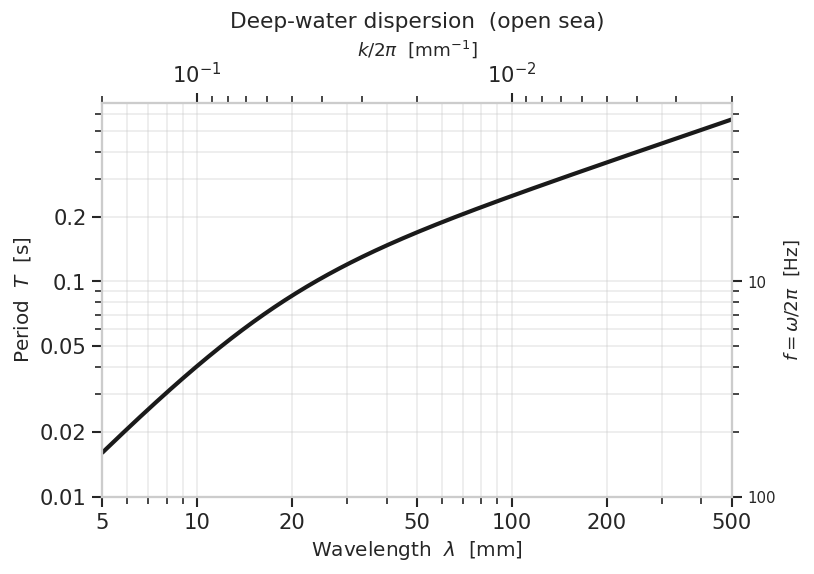

In [32]:
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({'text.usetex': False, 'figure.dpi': 120})

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(lam_mm, T, 'k-', lw=2.5)

# explicit T ticks on primary y-axis
T_ticks = [0.01, 0.02, 0.05, 0.1, 0.2]
ax.set_yticks(T_ticks)
ax.set_yticklabels([str(t) for t in T_ticks])

# explicit wavelength ticks on primary x-axis
lam_ticks = [5, 10, 20, 50, 100, 200, 500]
ax.set_xticks(lam_ticks)
ax.set_xticklabels([str(l) for l in lam_ticks])

ax.set_xlabel(r'Wavelength  $\lambda$  [mm]', fontsize=12)
ax.set_ylabel(r'Period  $T$  [s]', fontsize=12)
ax.set_title('Deep-water dispersion  (open sea)', fontsize=13)
ax.set_xlim(lam_mm[-1], lam_mm[0])   # long to short left-to-right
ax.grid(True, which='both', alpha=0.4)

# secondary x-axis: k/(2pi) in mm^{-1}
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(kover2pi[0], kover2pi[-1])
ax2.invert_xaxis()
ax2.set_xlabel(r'$k/2\pi$  [mm$^{-1}$]', fontsize=11)


# secondary y-axis: sparse frequency labels
ax3 = ax.twinx()
ax3.set_yscale('log')
ax3.set_ylim(ax.get_ylim())
ax3.set_ylabel(r'$f = \omega/2\pi$  [Hz]', fontsize=11)
ax3.set_yticks([1/fh for fh in [10, 100]])
ax3.set_yticklabels(['10', '100'], fontsize=9)

ax2.grid(False)
ax3.grid(False)

plt.tight_layout()
plt.savefig('fig1_dispersion.pdf', bbox_inches='tight')
plt.show()

---
## 4 — Force-balance ratios relative to gravity

Each ratio is formed as **[force scale] / [gravity restoring scale]** using
$\omega_0^2 = gk + T_0k^3/\rho$ as the full reference.

| Ratio | Expression | Meaning |
|---|---|---|
| Capillary / gravity | $T_0k^2/(\rho g)$ | when = 1, capillary = gravity |
| Bulk viscous | $2\nu k^2/\omega_0$ | viscous damping relative to oscillation rate |
| Elastic | $k_e k^2/(\rho\,\omega_0^2)$ | surface elasticity vs restoring force |
| Viscous surface | $k_v\omega_0 k^2/(\rho\,\omega_0^2) = k_v k^2/(\rho\,\omega_0)$ | dilational viscosity vs restoring force |

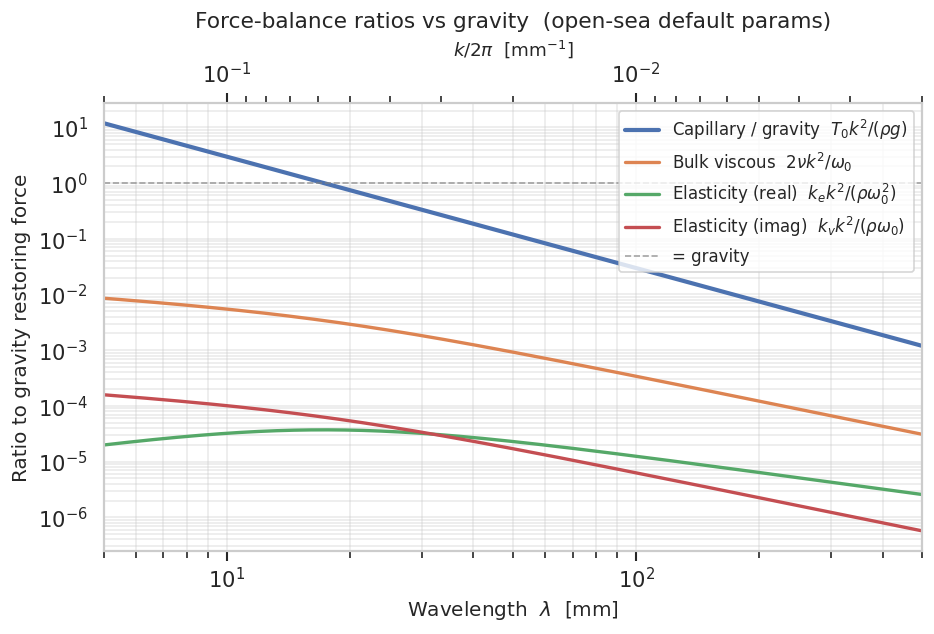

In [35]:
rho, nu, g, T0 = PARAMS['rho'], PARAMS['nu'], PARAMS['g'], PARAMS['T0']
k_e, k_v       = PARAMS['k_e'], PARAMS['k_v']

om0     = np.sqrt(g*k_arr + T0/rho * k_arr**3)   # real reference frequency
om0_sq  = om0**2

# Ratios
R_cap   = T0 * k_arr**2 / (rho * g)              # capillary / gravity  (= T0k^2/rho*g)
R_visc  = 2 * nu * k_arr**2 / om0                 # bulk viscous / oscillation rate
R_elast = k_e * k_arr**2 / (rho * om0_sq)         # elastic (real part of E) / restoring
R_evisc = k_v * k_arr**2 / (rho * om0)            # dilational viscous (imag E) / restoring

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.loglog(lam_mm, R_cap,   color='C0', lw=2.5, label=r'Capillary / gravity  $T_0k^2/(\rho g)$')
ax.loglog(lam_mm, R_visc,  color='C1', lw=2.0, label=r'Bulk viscous  $2\nu k^2/\omega_0$')
ax.loglog(lam_mm, R_elast, color='C2', lw=2.0, label=r'Elasticity (real)  $k_e k^2/(\rho\omega_0^2)$')
ax.loglog(lam_mm, R_evisc, color='C3', lw=2.0, label=r'Elasticity (imag)  $k_v k^2/(\rho\omega_0)$')

ax.axhline(1, color='gray', lw=1.0, ls='--', alpha=0.7, label='= gravity')

ax.set_xlabel(r'Wavelength  $\lambda$  [mm]', fontsize=12)
ax.set_ylabel('Ratio to gravity restoring force', fontsize=12)
ax.set_title('Force-balance ratios vs gravity  (open-sea default params)', fontsize=13)
ax.set_xlim(lam_mm[-1], lam_mm[0])
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.4)

# secondary x-axis
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(kover2pi[-1], kover2pi[0])
ax2.set_xlabel(r'$k/2\pi$  [mm$^{-1}$]', fontsize=11)
ax2.grid(False)

plt.tight_layout()
plt.savefig('fig2_force_ratios.pdf', bbox_inches='tight')
plt.show()

---
## 5 — Damping: Q factor and spatial decay length

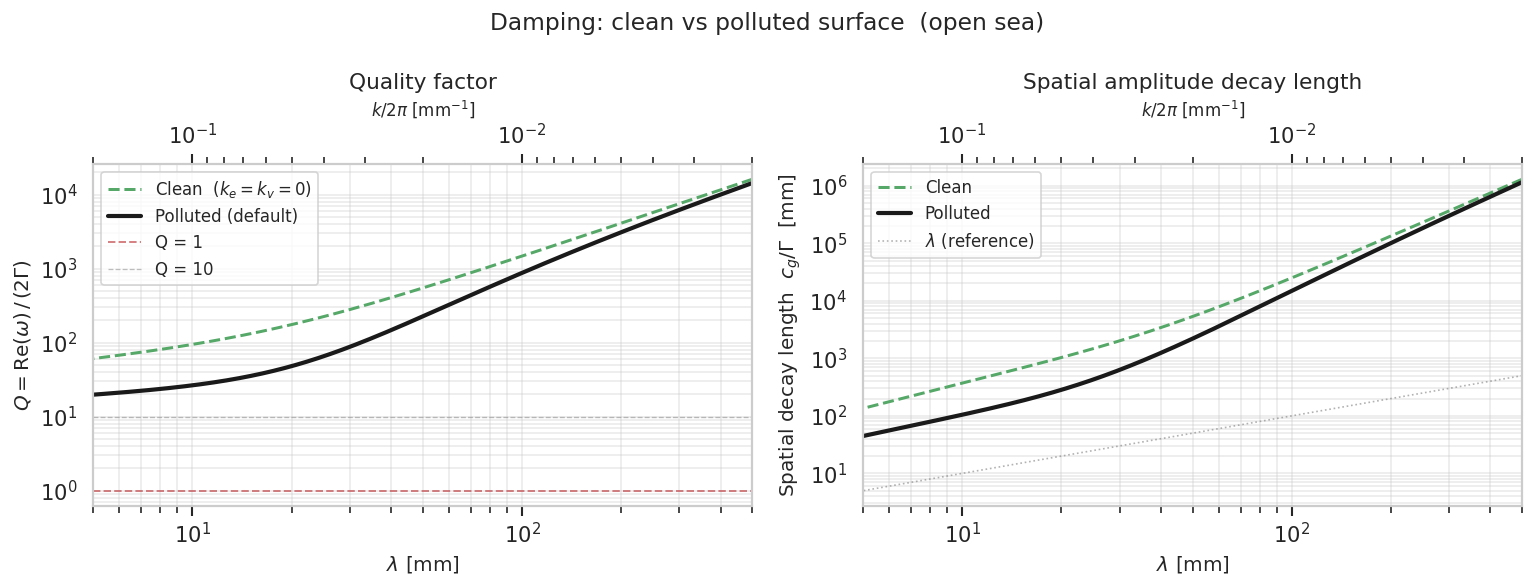

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(lam_mm, Q_clean, 'g--', lw=1.8, label='Clean  ($k_e=k_v=0$)')
ax.loglog(lam_mm, Q,       'k-',  lw=2.5, label='Polluted (default)')
ax.axhline(1,  color='r',    lw=1.2, ls='--', alpha=0.7, label='Q = 1')
ax.axhline(10, color='gray', lw=0.8, ls='--', alpha=0.5, label='Q = 10')
ax.set_xlabel(r'$\lambda$ [mm]', fontsize=12)
ax.set_ylabel(r'$Q = \mathrm{Re}(\omega)\,/\,(2\Gamma)$', fontsize=12)
ax.set_title('Quality factor', fontsize=13)
ax.set_xlim(lam_mm[-1], lam_mm[0])
ax.legend(fontsize=10)

ax = axes[1]
ax.loglog(lam_mm, L_decay_c, 'g--', lw=1.8, label='Clean')
ax.loglog(lam_mm, L_decay,   'k-',  lw=2.5, label='Polluted')
ax.loglog(lam_mm, lam_mm, color='gray', lw=1, ls=':', alpha=0.6,
          label=r'$\lambda$ (reference)')
ax.set_xlabel(r'$\lambda$ [mm]', fontsize=12)
ax.set_ylabel(r'Spatial decay length  $c_g/\Gamma$  [mm]', fontsize=12)
ax.set_title('Spatial amplitude decay length', fontsize=13)
ax.set_xlim(lam_mm[-1], lam_mm[0])
ax.legend(fontsize=10)

for ax in axes:
    ax.grid(True, which='both', alpha=0.4)
    ax2 = ax.twiny()
    ax2.set_xscale('log')
    ax2.set_xlim(kover2pi[-1], kover2pi[0])
    ax2.set_xlabel(r'$k/2\pi$ [mm$^{-1}$]', fontsize=10)
    ax2.grid(False)

fig.suptitle('Damping: clean vs polluted surface  (open sea)', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_damping.pdf', bbox_inches='tight')
plt.show()

---
## 6 — Marangoni effect across contamination levels

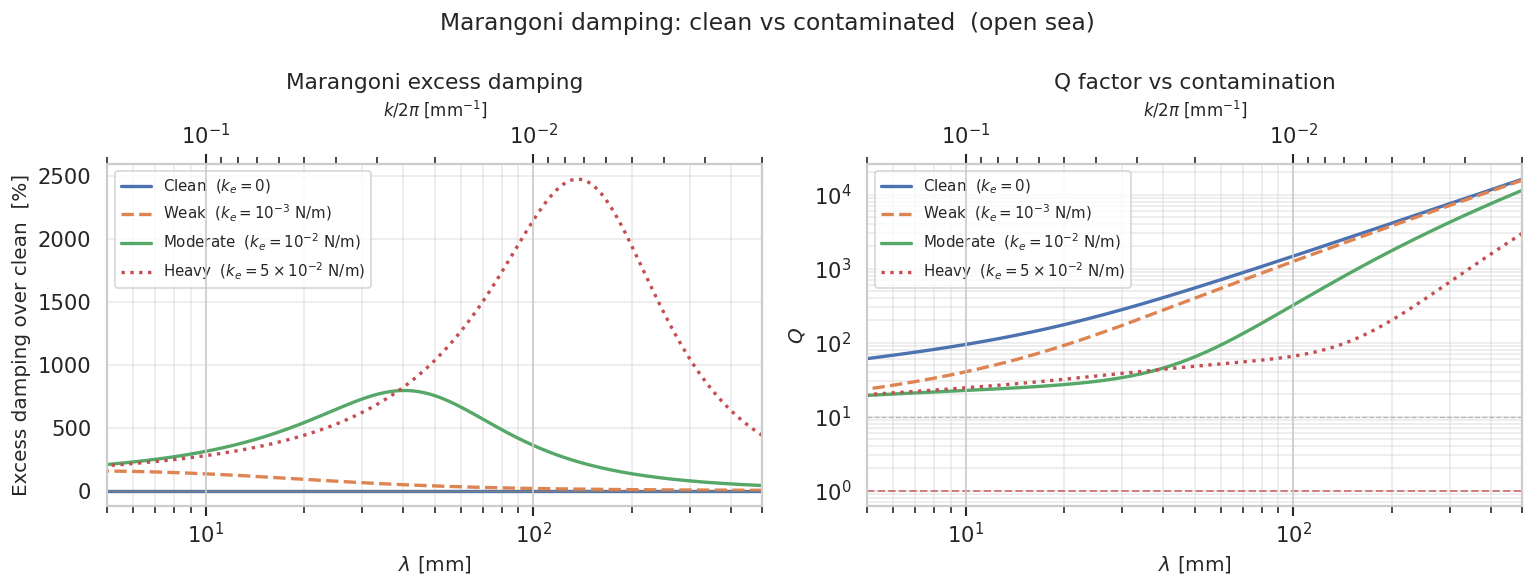

In [36]:
cases = [
    (r'Clean  ($k_e=0$)',                  dict(PARAMS, k_e=0.0,  k_v=0.0),  'C0', '-'),
    (r'Weak  ($k_e=10^{-3}$ N/m)',         dict(PARAMS, k_e=1e-3, k_v=1e-5), 'C1', '--'),
    (r'Moderate  ($k_e=10^{-2}$ N/m)',     dict(PARAMS, k_e=1e-2, k_v=1e-4), 'C2', '-'),
    (r'Heavy  ($k_e=5\times10^{-2}$ N/m)', dict(PARAMS, k_e=5e-2, k_v=5e-4), 'C3', ':'),
]

Gamma_ref = -solve(k_arr, dict(PARAMS, k_e=0, k_v=0)).imag
om0_ref   = np.sqrt(PARAMS['g']*k_arr + PARAMS['T0']/PARAMS['rho']*k_arr**3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, pc, col, ls in cases:
    om_c  = solve(k_arr, pc)
    Gc    = -om_c.imag
    Qc    = om_c.real / (2*Gc)
    excess = (Gc - Gamma_ref) / (Gamma_ref + 1e-300) * 100
    axes[0].semilogx(lam_mm, excess, color=col, ls=ls, lw=2, label=label)
    axes[1].loglog(  lam_mm, Qc,     color=col, ls=ls, lw=2, label=label)

axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_xlabel(r'$\lambda$ [mm]', fontsize=12)
axes[0].set_ylabel('Excess damping over clean  [%]', fontsize=12)
axes[0].set_title('Marangoni excess damping', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].set_xlim(lam_mm[-1], lam_mm[0])

axes[1].axhline(1,  color='r',    lw=1.2, ls='--', alpha=0.7)
axes[1].axhline(10, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[1].set_xlabel(r'$\lambda$ [mm]', fontsize=12)
axes[1].set_ylabel(r'$Q$', fontsize=12)
axes[1].set_title('Q factor vs contamination', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_xlim(lam_mm[-1], lam_mm[0])

for ax in axes:
    ax.grid(True, which='both', alpha=0.4)
    ax2 = ax.twiny()
    ax2.set_xscale('log')
    ax2.set_xlim(kover2pi[-1], kover2pi[0])
    ax2.set_xlabel(r'$k/2\pi$ [mm$^{-1}$]', fontsize=10)

fig.suptitle('Marangoni damping: clean vs contaminated  (open sea)', fontsize=14)
plt.tight_layout()
plt.savefig('fig4_marangoni.pdf', bbox_inches='tight')
plt.show()

---
## 7 — Cross-check against `dispersion.py`

Place `dispersion.py` in the same directory.  Compares
$\mathrm{Re}(\omega)$ against `_w_gc` (inviscid finite-depth, which
equals the deep-water result for large $kH$) and $\Gamma$ against
`find_roots_newton`.

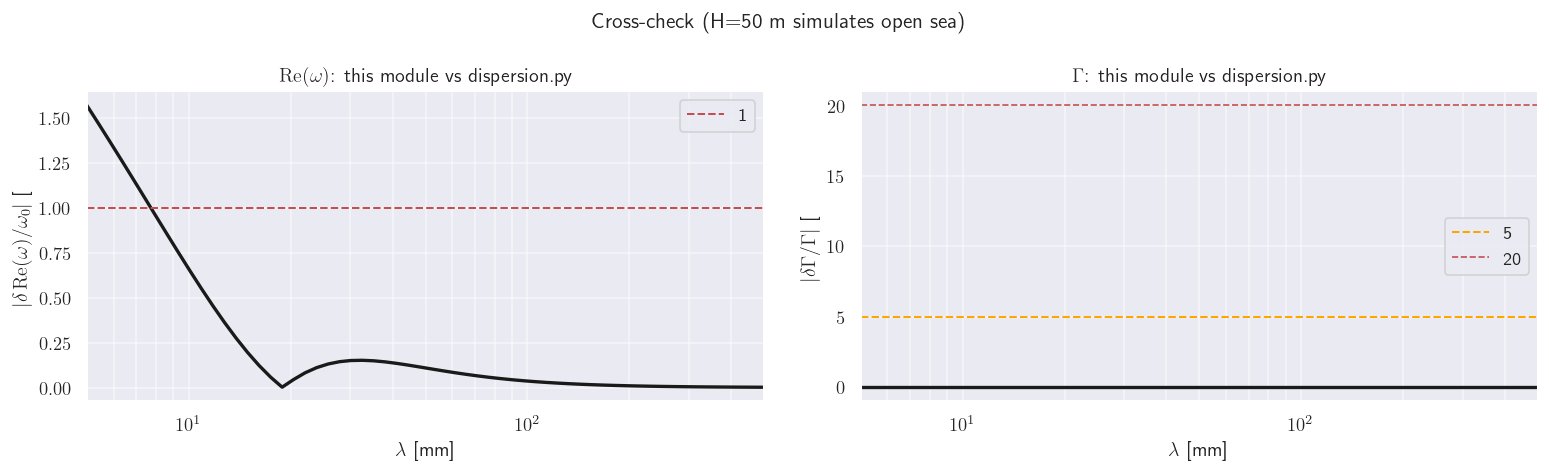

In [37]:
try:
    import importlib.util
    spec = importlib.util.spec_from_file_location('dispersion', 'dispersion.py')
    disp = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(disp)

    # use a subset for speed
    idx    = np.round(np.linspace(0, len(k_arr)-1, 60)).astype(int)
    k_sub  = k_arr[idx]
    lam_sub = lam_mm[idx]
    om_sub = om[idx]

    # finite-depth reference  (add a large H to mimic deep water)
    p_fd = dict(PARAMS, H=50.0)
    om_fd_re = np.array([disp._w_gc(k, p_fd['rho'], p_fd['g'],
                                     p_fd['T0'], p_fd['H']) for k in k_sub])
    om_fd_full = []
    for k in k_sub:
        roots = disp.find_roots_newton(k, p_fd)
        gc    = disp._gc_root(roots)
        om_fd_full.append(gc if gc is not None else complex(np.nan))
    om_fd_full = np.array(om_fd_full)

    err_re = np.abs(om_sub.real - om_fd_re) / om_fd_re * 100
    valid  = np.isfinite(om_fd_full.imag) & (om_fd_full.imag < 0)
    err_im = np.abs(om_sub.imag - om_fd_full.imag)[valid] \
             / np.abs(om_fd_full.imag[valid]) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].semilogx(lam_sub, err_re, 'k-', lw=2)
    axes[0].axhline(1, color='r', lw=1.2, ls='--', label='1%')
    axes[0].set_xlabel(r'$\lambda$ [mm]')
    axes[0].set_ylabel(r'$|\delta\,\mathrm{Re}(\omega)/\omega_0|$ [%]')
    axes[0].set_title(r'$\mathrm{Re}(\omega)$: this module vs dispersion.py')
    axes[0].set_xlim(lam_sub[-1], lam_sub[0])
    axes[0].legend(); axes[0].grid(True, which='both', alpha=0.5)

    axes[1].semilogx(lam_sub[valid], err_im, 'k-', lw=2)
    axes[1].axhline(5,  color='orange', lw=1.2, ls='--', label='5%')
    axes[1].axhline(20, color='r',      lw=1.0, ls='--', label='20%')
    axes[1].set_xlabel(r'$\lambda$ [mm]')
    axes[1].set_ylabel(r'$|\delta\Gamma/\Gamma|$ [%]')
    axes[1].set_title(r'$\Gamma$: this module vs dispersion.py')
    axes[1].set_xlim(lam_sub[-1], lam_sub[0])
    axes[1].legend(); axes[1].grid(True, which='both', alpha=0.5)

    fig.suptitle('Cross-check (H=50 m simulates open sea)', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig5_crosscheck.pdf', bbox_inches='tight')
    plt.show()

except Exception as exc:
    print(f'Skipped: {exc}')